<a href="https://colab.research.google.com/github/qvinh28/CV2/blob/main/ASM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

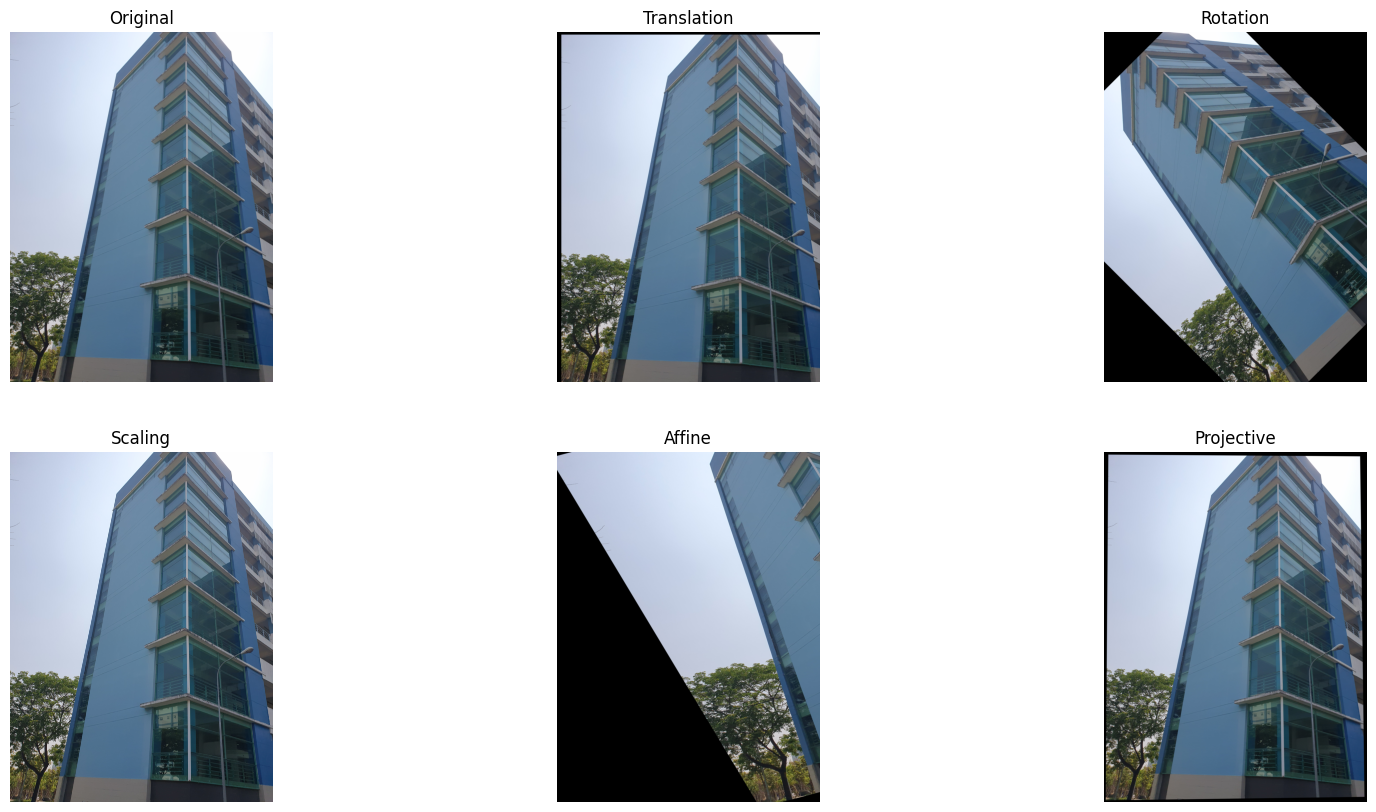

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_images(images, titles, figsize=(15, 7)):
    plt.figure(figsize=figsize)
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

img = cv2.imread('/content/bg2.jpg')
rows, cols, ch = img.shape
# 1 Translation
# Dịch chuyển sang phải 50px, xuống dưới 30px
M_trans = np.float32([[1, 0, 50], [0, 1, 30]])
dst_trans = cv2.warpAffine(img, M_trans, (cols, rows))

# 2 Rotation
# Xoay 45 độ quanh tâm ảnh, giữ nguyên tỉ lệ 1.0
center = (cols // 2, rows // 2)
M_rot = cv2.getRotationMatrix2D(center, 45, 1.0)
dst_rot = cv2.warpAffine(img, M_rot, (cols, rows))

# 3 Scaling
# Phóng to ảnh gấp 1.5 lần
dst_scale = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)

# 4 Affine Transformation
# Cần 3 điểm tương ứng để xác định ma trận 2x3
pts1_aff = np.float32([[50, 50], [200, 50], [50, 200]])
pts2_aff = np.float32([[10, 100], [200, 50], [100, 250]])
M_affine = cv2.getAffineTransform(pts1_aff, pts2_aff)
dst_affine = cv2.warpAffine(img, M_affine, (cols, rows))

# 5 Projective Transformation (Homography)
# Cần 4 điểm tương ứng để xác định ma trận 3x3
pts1_proj = np.float32([[0, 0], [cols-1, 0], [0, rows-1], [cols-1, rows-1]])
pts2_proj = np.float32([[50, 30], [cols-80, 50], [20, rows-20], [cols-30, rows-60]])
M_homo = cv2.getPerspectiveTransform(pts1_proj, pts2_proj)
dst_proj = cv2.warpPerspective(img, M_homo, (cols, rows))

# Hiển thị kết quả so sánh
titles = ['Original', 'Translation', 'Rotation', 'Scaling', 'Affine', 'Projective']
images = [img, dst_trans, dst_rot, dst_scale, dst_affine, dst_proj]

plt.figure(figsize=(20, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    # Chuyển BGR sang RGB để hiển thị đúng màu trên Matplotlib
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')
plt.show()

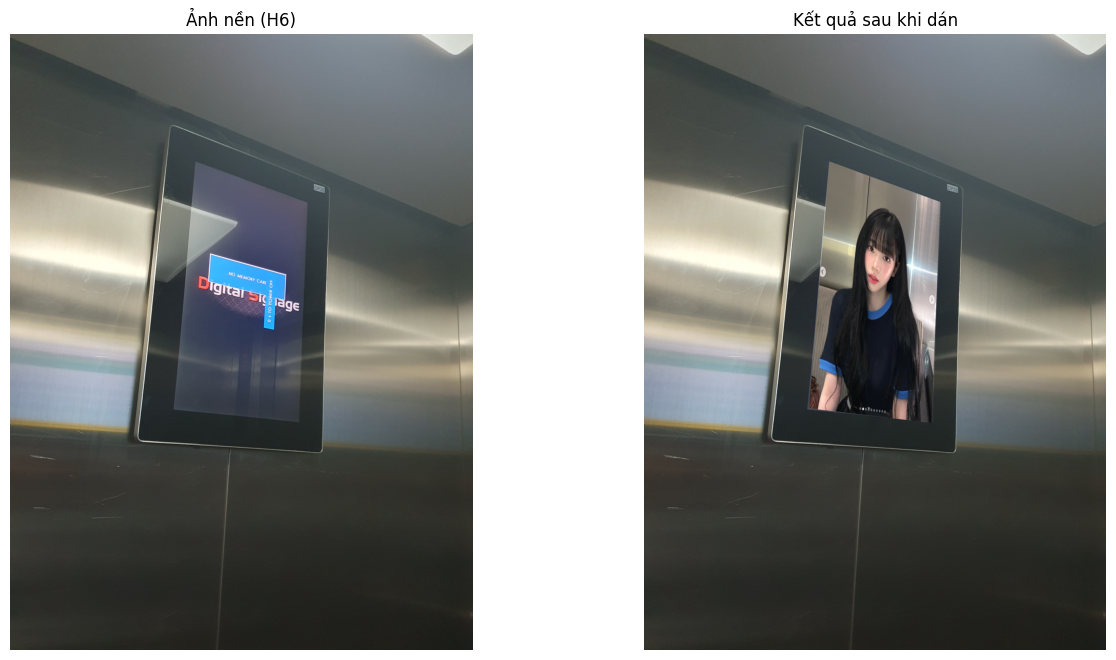

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_results(imgs, titles):
    plt.figure(figsize=(15, 8))
    for i, (img, title) in enumerate(zip(imgs, titles)):
        plt.subplot(1, len(imgs), i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.show()

background = cv2.imread('/content/bg1.jpg')
source_img = cv2.imread('/content/image.jpg')

if background is None or source_img is None:
    print("Lỗi: Hãy kiểm tra lại đường dẫn ảnh trên Colab.")
else:
    # Xác định điểm (manual)
    # Tọa độ 4 góc của ảnh nguồn (ảnh cá nhân)
    h_src, w_src = source_img.shape[:2]
    pts_src = np.float32([[0, 0], [w_src-1, 0], [w_src-1, h_src-1], [0, h_src-1]])

    # Tọa độ 4 góc vùng mặt phẳng đích trên ảnh tòa nhà H6
    # Thứ tự: Trên-Trái, Trên-Phải, Dưới-Phải, Dưới-Trái
    pts_dst = np.float32([[1214, 836], [1938, 1100], [1881, 2544], [1080, 2448]])

    # Projective Transformation
    # Tính ma trận Homography
    H, status = cv2.findHomography(pts_src, pts_dst)

    # Biến đổi ảnh nguồn sang khung hình của ảnh nền
    warped_img = cv2.warpPerspective(source_img, H, (background.shape[1], background.shape[0]))

    # Lồng ghép (Blending)
    # Tạo mặt nạ (mask) cho vùng đích
    mask = np.zeros((background.shape[0], background.shape[1]), dtype=np.uint8)
    cv2.fillConvexPoly(mask, pts_dst.astype(int), 255)

    # Cắt bỏ vùng nền nơi sẽ dán ảnh vào
    mask_inv = cv2.bitwise_not(mask)
    background_bg = cv2.bitwise_and(background, background, mask=mask_inv)

    # Kết hợp ảnh đã warp và ảnh nền
    final_result = cv2.add(background_bg, warped_img)

    show_results([background, final_result], ['Ảnh nền (H6)', 'Kết quả sau khi dán'])